Loading the dataset and cleaning:

In [8]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/ride_booking_dataset.csv")

# Preview data
print(df.head())
print(df.info())

# Check null values
print(df.isnull().sum())

# Fill categorical nulls with 'Unknown'
categorical_cols = ['Booking_Status', 'Vehicle_Type', 'Payment_Method']

for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

# Fill numerical nulls with median
numerical_cols = ['Ride_Distance_km', 'Fare_Amount']

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Check duplicates
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Convert Time column properly
df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.time

# Remove negative or zero fare
df = df[df['Fare_Amount'] > 0]

# Remove unrealistic distance (example: >100 km)
df = df[df['Ride_Distance_km'] <= 100]

# Extract Hour from Time
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.hour

# Extract Day Name
df['Day'] = df['Date'].dt.day_name()

print("Final Shape:", df.shape)
print(df.isnull().sum())

  Booking_ID        Date   Time Booking_Status Customer_ID Driver_ID  \
0      B1000  2024-01-07  16:20        Success        C138       D75   
1      B1001  2024-01-20  13:08        Success        C145      D197   
2      B1002  2024-01-29  13:00        Success        C177      D103   
3      B1003  2024-01-15  18:44        Success        C220      D107   
4      B1004  2024-01-11  12:03        Success        C183       D64   

  Vehicle_Type  Ride_Distance_km  Fare_Amount Payment_Method  
0         Bike             17.75       452.14           Card  
1  Prime Sedan              3.31        83.59            UPI  
2         Auto             13.06       458.48            UPI  
3         Auto             12.06       498.45            UPI  
4         Auto              3.25       365.19           Card  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            -------------

/tmp/ipykernel_489/1061106075.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.time


Analysis

In [9]:
# Success Rate
success_rate = (df['Booking_Status'] == 'Success').mean() * 100

# Revenue
revenue = df[df['Booking_Status']=='Success']['Fare_Amount'].sum()

print(success_rate, revenue)

69.3 184421.87


Visualisations:

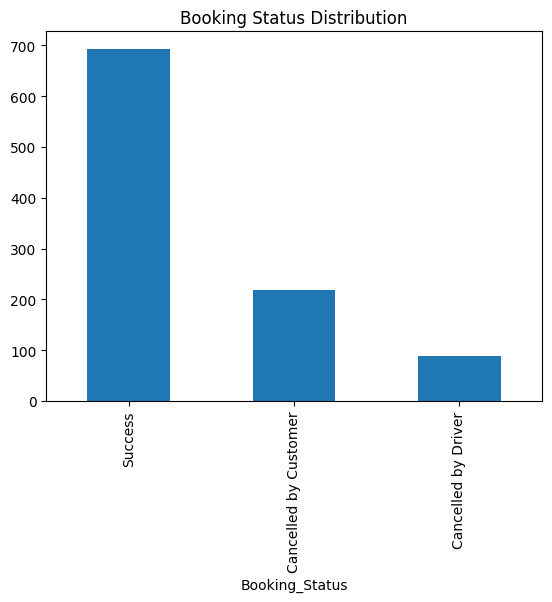

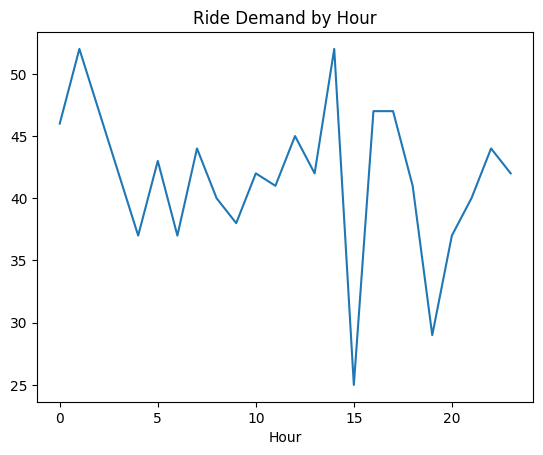

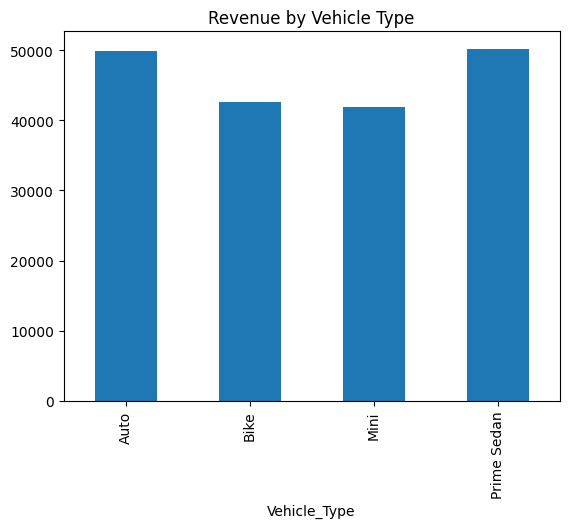

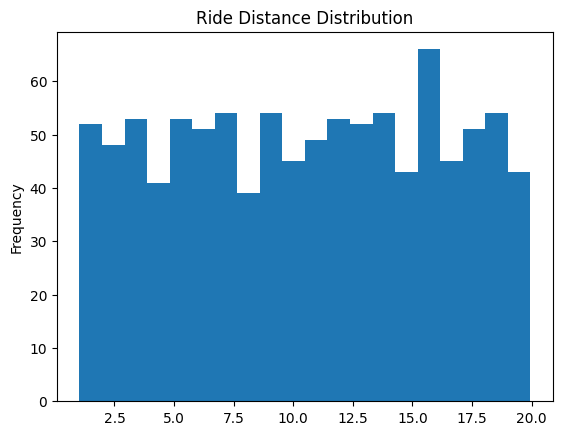

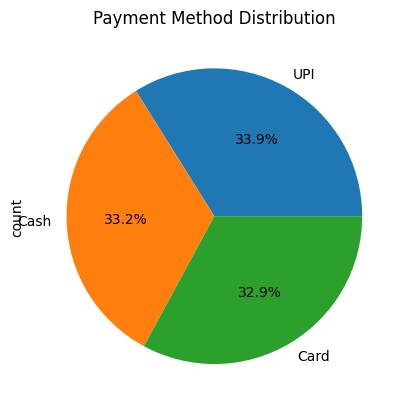

In [10]:
import matplotlib.pyplot as plt

# Booking Status
df['Booking_Status'].value_counts().plot(kind='bar')
plt.title('Booking Status Distribution')
plt.show()

# Peak Hour Demand
df['Hour'].value_counts().sort_index().plot(kind='line')
plt.title('Ride Demand by Hour')
plt.show()

# Revenue by Vehicle
df[df['Booking_Status']=='Success'].groupby('Vehicle_Type')['Fare_Amount'].sum().plot(kind='bar')
plt.title('Revenue by Vehicle Type')
plt.show()

# Distance Distribution
df['Ride_Distance_km'].plot(kind='hist', bins=20)
plt.title('Ride Distance Distribution')
plt.show()

# Payment Method
df['Payment_Method'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.show()